# Búsqueda de imágenes por texto (CLIP)

Carga un modelo entrenado desde `checkpoints/`, recibe una consulta de texto y recupera las
N imágenes más similares del dataset **flickr8k**, mostrando el texto de la consulta junto a
las imágenes encontradas.

Cada experimento de `checkpoints/` es una carpeta con los pesos (`best.pt`) y un `hparams.json`
que describe cómo reconstruir el modelo. Los experimentos anteriores a la introducción de ese
fichero no son cargables (no se sabe qué conectores usaron): hay que reentrenarlos.

Ajusta la celda de **configuración** y ejecuta las celdas en orden.

## 1. Configuración

In [19]:
import os

# Carpeta del experimento dentro de checkpoints/ (nombre o ruta completa).
# Si es None, se usa el experimento cargable más reciente.
EXPERIMENT_DIR = "resnet50_answerdotai-ModernBERT-base_imgmlp_txtmlp_bs32_ep4_flickr8k_20260710-105500"

# Raíz del proyecto (carpeta padre de notebooks/).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
DATASET_DIR = os.path.join(PROJECT_ROOT, "datasets", "flickr8k")

# Número de imágenes a recuperar y mostrar (configurable).
N_RESULTS = 9

# Tamaño de lote para calcular los embeddings de las imágenes.
BATCH_SIZE = 64

## 2. Imports

In [20]:
import sys
import math

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import albumentations as A
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# Hacer importable el paquete src/ del proyecto.
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from models.checkpoint import list_experiments, load_clip_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 3. Elegir el experimento

Cada subcarpeta de `checkpoints/` es un experimento. Es cargable si tiene `hparams.json`
(los argumentos con los que se construyó el `CLIPModel`) y su fichero de pesos.

Si `EXPERIMENT_DIR` es `None` se toma el experimento cargable más reciente (`list_experiments`
los devuelve en orden cronológico, leyendo el timestamp del final del nombre).

In [21]:
experiments = list_experiments(CHECKPOINTS_DIR)

for exp in experiments:
    if exp["loadable"]:
        m = exp["hparams"]["model"]
        d = exp["hparams"]["data"]
        detail = (
            f'{m["image_encoder_alias"]} + {m["text_encoder_alias"]} | '
            f'conectores: img={m["image_connector"]}, txt={m["text_connector"]} | '
            f'proj={m["projection_dims"]} | {d["dataset_name"]}'
        )
        print(f'[ok] {exp["name"]}\n     {detail}')
    else:
        motivo = exp["error"].split(".")[0]
        print(f'[--] {exp["name"]}\n     no cargable: {motivo}')

if EXPERIMENT_DIR is None:
    loadable = [e for e in experiments if e["loadable"]]
    if not loadable:
        raise FileNotFoundError(
            f"Ningún experimento cargable en {CHECKPOINTS_DIR!r}. Entrena uno con "
            f"src/trainers/trainer.py para que se escriba su hparams.json."
        )
    EXPERIMENT_DIR = loadable[-1]["path"]
elif not os.path.isabs(EXPERIMENT_DIR):
    EXPERIMENT_DIR = os.path.join(CHECKPOINTS_DIR, EXPERIMENT_DIR)

print("\nExperimento seleccionado:", EXPERIMENT_DIR)

[ok] resnet50_distilbert-base-uncased_imgmlp_txtmlp_bs32_ep4_flickr8k_20260710-095037
     resnet50 + distilbert-base-uncased | conectores: img=mlp, txt=mlp | proj=256 | flickr8k
[ok] resnet50_distilbert-base-uncased_imglinear_txtlinear_bs32_ep1_flickr8k_20260710-101713
     resnet50 + distilbert-base-uncased | conectores: img=linear, txt=linear | proj=256 | flickr8k
[ok] resnet50_distilbert-base-uncased_imglinear_txtlinear_bs32_ep4_flickr8k_20260710-101958
     resnet50 + distilbert-base-uncased | conectores: img=linear, txt=linear | proj=256 | flickr8k
[--] resnet50_distilbert-base-uncased_imgswiglu_txtswiglu_bs32_ep4_flickr8k_20260710-102958
     no cargable: Falta el fichero de pesos 'best
[ok] resnet50_distilbert-base-uncased_imgswiglu_txtswiglu_bs32_ep4_flickr8k_20260710-103105
     resnet50 + distilbert-base-uncased | conectores: img=swiglu, txt=swiglu | proj=256 | flickr8k
[ok] resnet50_distilbert-base-uncased_imglinear_txtmlp_bs32_ep4_flickr8k_20260710-103715
     resnet50 + d

## 4. Cargar el modelo

In [22]:
model, hparams = load_clip_model(EXPERIMENT_DIR, map_location=DEVICE)
model.to(DEVICE)

IMAGE_SIZE = hparams["data"]["size"]
TEXT_ENCODER_ALIAS = hparams["model"]["text_encoder_alias"]

print("Modelo cargado desde:", EXPERIMENT_DIR)
print("Tamaño de imagen:", IMAGE_SIZE, "| tokenizador:", TEXT_ENCODER_ALIAS)

Modelo cargado desde: /home/miguel/projects/clip_implementation/checkpoints/resnet50_answerdotai-ModernBERT-base_imgmlp_txtmlp_bs32_ep4_flickr8k_20260710-105500
Tamaño de imagen: 224 | tokenizador: answerdotai/ModernBERT-base


## 5. Lista de imágenes únicas del dataset

In [23]:
annotations = pd.read_csv(os.path.join(DATASET_DIR, "captions.txt"))
image_filenames = annotations["image"].unique().tolist()
image_paths = [os.path.join(DATASET_DIR, "Images", f) for f in image_filenames]
print(f"{len(image_paths)} imágenes únicas")

8091 imágenes únicas


## 6. Calcular los embeddings de todas las imágenes

Se replica el mismo preprocesado que en entrenamiento (cv2 BGR→RGB, `Resize`, `Normalize`).
Este paso recorre las ~8091 imágenes una sola vez; en CPU puede tardar unos minutos.

In [24]:
transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(max_pixel_value=255.0),
])

def preprocess_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transforms(image=image)["image"]
    return torch.tensor(image).permute(2, 0, 1).float()


@torch.no_grad()
def compute_image_embeddings(paths, batch_size=BATCH_SIZE):
    embeddings = []
    for start in tqdm(range(0, len(paths), batch_size), desc="Imágenes"):
        batch_paths = paths[start:start + batch_size]
        batch = torch.stack([preprocess_image(p) for p in batch_paths]).to(DEVICE)
        features = model.image_encoder(batch)
        embeddings.append(model.image_projection(features).cpu())
    return torch.cat(embeddings)


image_embeddings = compute_image_embeddings(image_paths)
print("image_embeddings:", tuple(image_embeddings.shape))

Imágenes: 100%|██████████| 127/127 [00:17<00:00,  7.09it/s]

image_embeddings: (8091, 256)


## 7. Buscar coincidencias para una consulta de texto

In [25]:
tokenizer = AutoTokenizer.from_pretrained(TEXT_ENCODER_ALIAS)


@torch.no_grad()
def find_matches(query, n=N_RESULTS):
    encoded = tokenizer([query], padding=True, truncation=True, return_tensors="pt")
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    text_features = model.text_encoder(
        input_ids=encoded["input_ids"], attention_mask=encoded["attention_mask"]
    )
    text_embeddings = model.text_projection(text_features).cpu()

    # La pérdida de entrenamiento no normaliza, pero para recuperar por similitud
    # coseno sí queremos comparar direcciones y no magnitudes.
    image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
    text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
    similarity = text_embeddings_n @ image_embeddings_n.T

    _, indices = torch.topk(similarity.squeeze(0), n)
    return [image_paths[i] for i in indices.tolist()]

## 8. Mostrar la consulta y las imágenes encontradas

In [26]:
def show_results(query, n=N_RESULTS):
    matches = find_matches(query, n=n)

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for ax, path in zip(axes, matches):
        image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.axis("off")
    for ax in axes[len(matches):]:
        ax.axis("off")

    fig.suptitle(f'Query: "{query}"  —  top {n}', fontsize=16)
    plt.tight_layout()
    plt.show()

## 9. Ejemplo de uso

Cambia el texto de la consulta y `N_RESULTS` para probar.

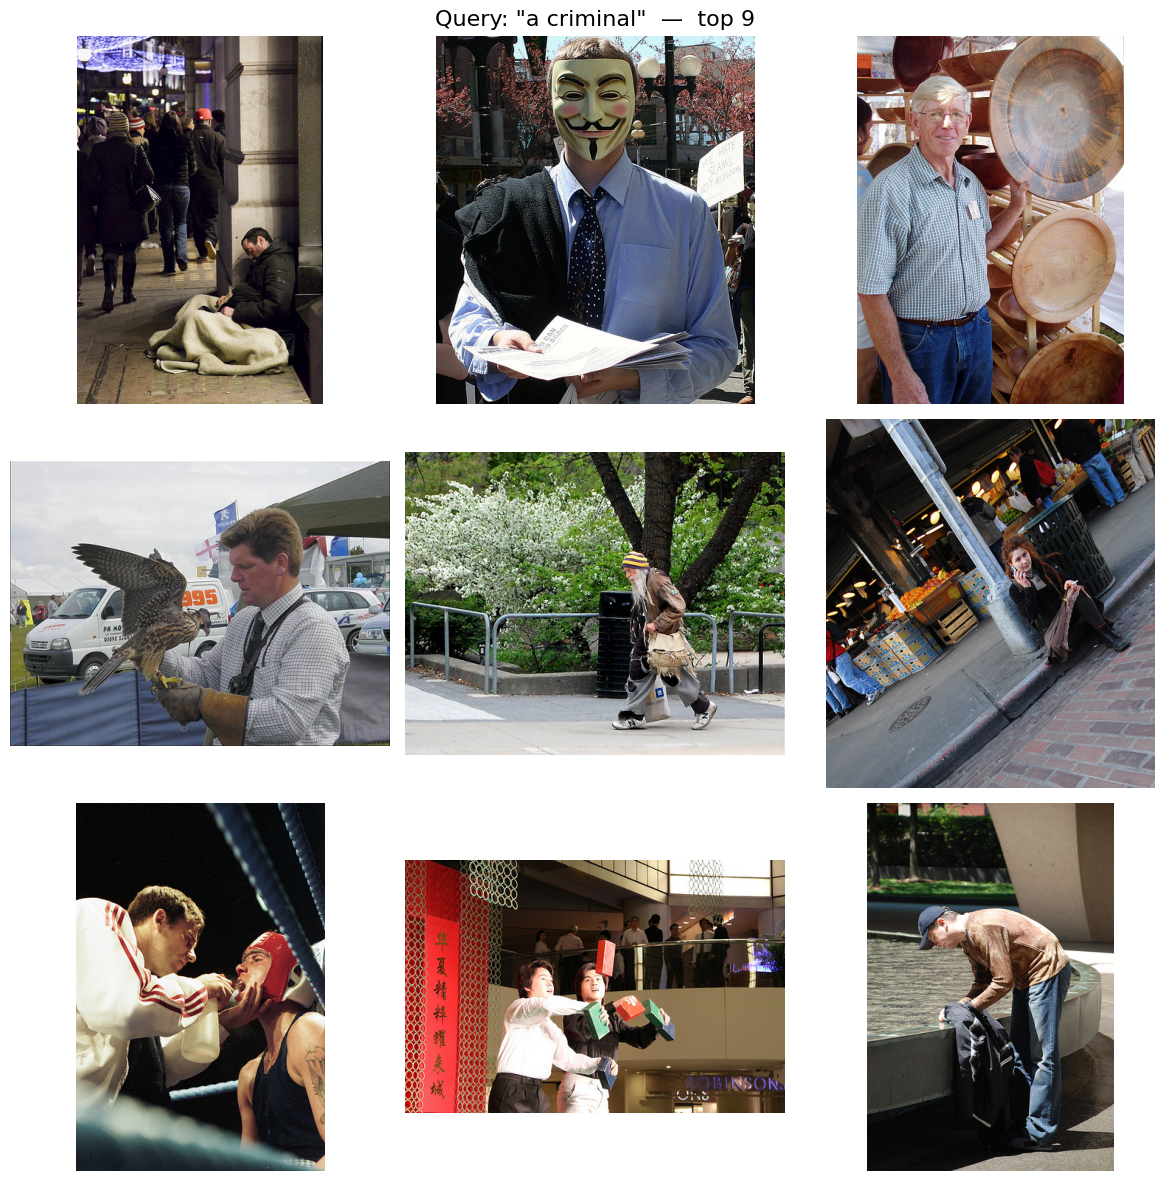

In [35]:
show_results("a criminal", n=N_RESULTS)